In [61]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata_new.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

mask = dat["wf_cost"] < 6e-5  # Filter bad samples
nmask = np.sum(mask)
nmask

40

Text(0, 0.5, 'U')

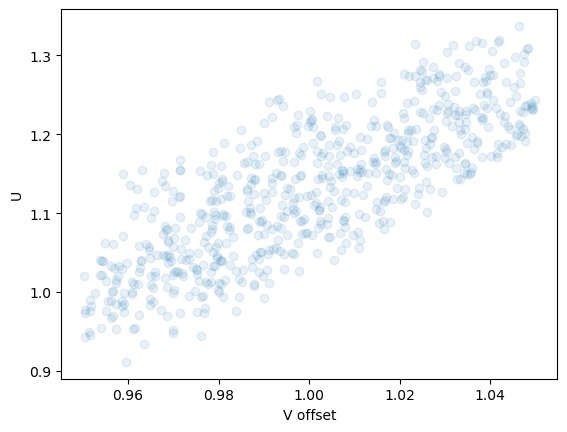

In [62]:
plt.scatter(dat["V_offset"][mask].flatten(), dat["U_i"][mask].flatten(), alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

(-0.05, 0.7)

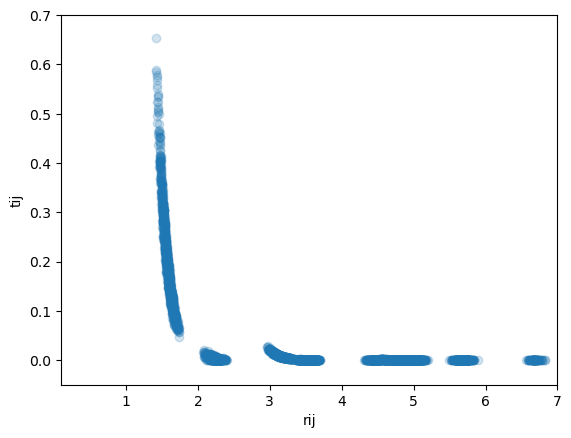

In [63]:
plt.scatter(dat["rij"][mask].flatten(), dat["t_ij"][mask].flatten(), alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

`wf_cost` is the final cost function values in Wannierization. `total_cost_func` is the variance sum of the Hubbard parameters.

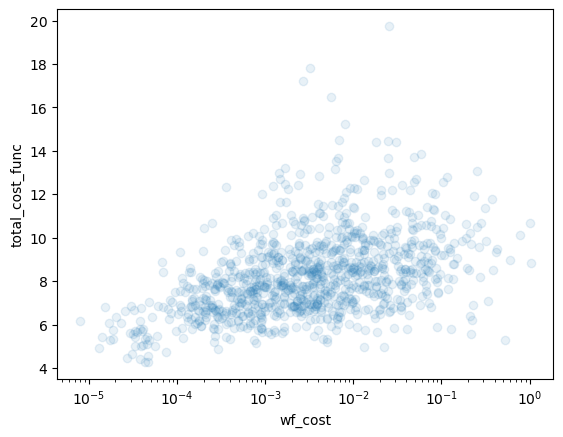

In [64]:
plt.scatter(dat["wf_cost"].flatten(), dat["total_cost_func"].flatten(), alpha=0.1)
plt.xlabel("wf_cost")
plt.ylabel("total_cost_func")
plt.xscale("log")

### Correlation to geometric factors

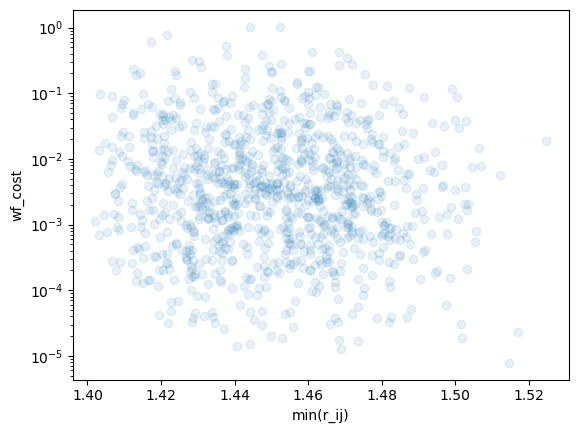

In [65]:
rmin = dat["rij"] + np.eye(N) * 100
rmin = np.min(rmin, axis=(1, 2))

plt.scatter(rmin, dat["wf_cost"], alpha=0.1)
plt.xlabel("min(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

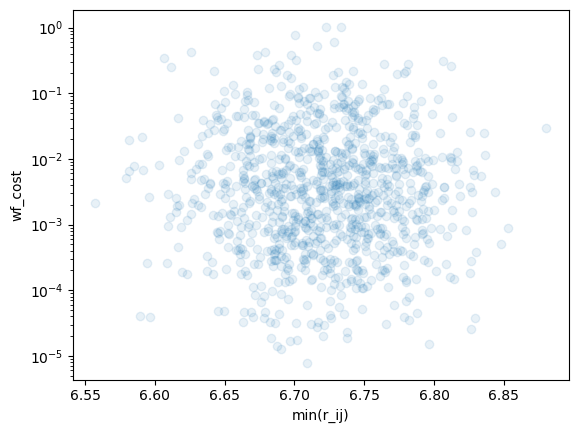

In [71]:
rmin = dat["rij"]
rmin = np.max(rmin, axis=(1, 2))

plt.scatter(rmin, dat["wf_cost"], alpha=0.1)
plt.xlabel("min(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

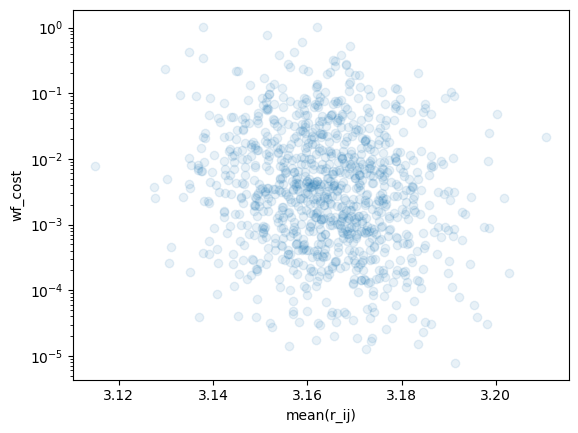

In [70]:
rmin = dat["rij"]
rmin = np.mean(rmin, axis=(1, 2))

plt.scatter(rmin, dat["wf_cost"], alpha=0.1)
plt.xlabel("mean(r_ij)")
plt.ylabel("wf_cost")
plt.yscale("log")

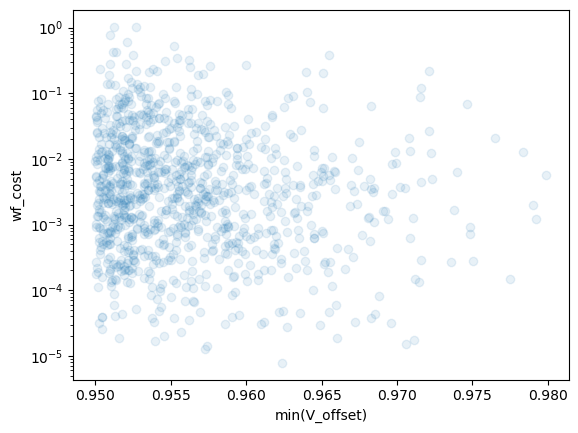

In [69]:
rmin = dat["V_offset"]
rmin = np.min(rmin, axis=1)

plt.scatter(rmin, dat["wf_cost"], alpha=0.1)
plt.xlabel("min(V_offset)")
plt.ylabel("wf_cost")
plt.yscale("log")

Wannierization failure doesn't seem to be clearly relevant to any single geometric factor.

What if I pile `wf_cost` and compare it with all `rij`?

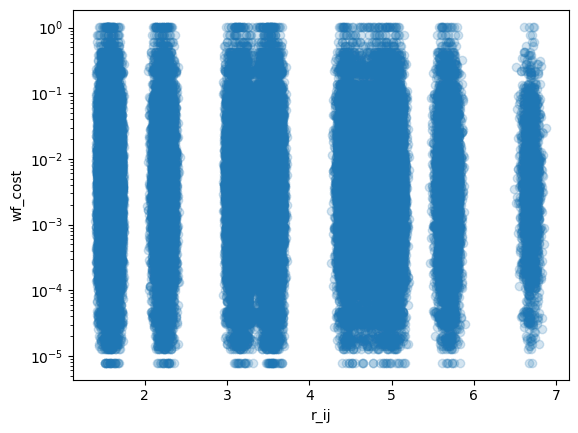

In [68]:
rmin = dat["rij"]
# Creating a mask that excludes the diagonal
mask = np.ones((N, N), dtype=bool)
np.fill_diagonal(mask, 0)

# Flattening the array
rmin = rmin.reshape(rmin.shape[0], -1)[:, mask.ravel()]
wfc = np.tile(dat["wf_cost"], (N**2 - N, 1)).T

plt.scatter(rmin.flatten(), wfc.flatten(), alpha=0.1)
plt.xlabel("r_ij")
plt.ylabel("wf_cost")
plt.yscale("log")

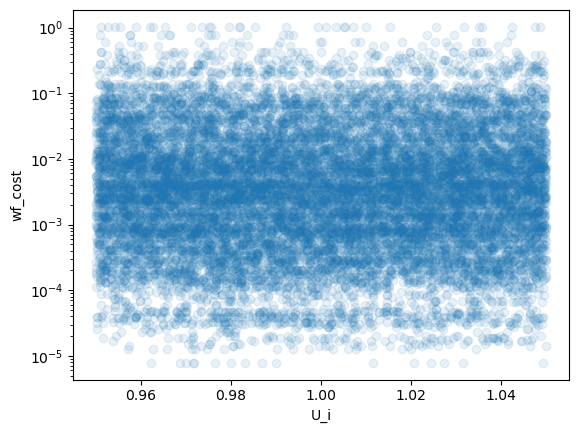

In [74]:
rmin = dat["V_offset"]
wfc = np.tile(dat["wf_cost"], (N, 1)).T

plt.scatter(rmin.flatten(), wfc.flatten(), alpha=0.1)
plt.xlabel("V_offset")
plt.ylabel("wf_cost")
plt.yscale("log")

No clear distinction on how geometric factors are distributed with higer or lower wf_cost.

### Correlation to Hubbard parameters

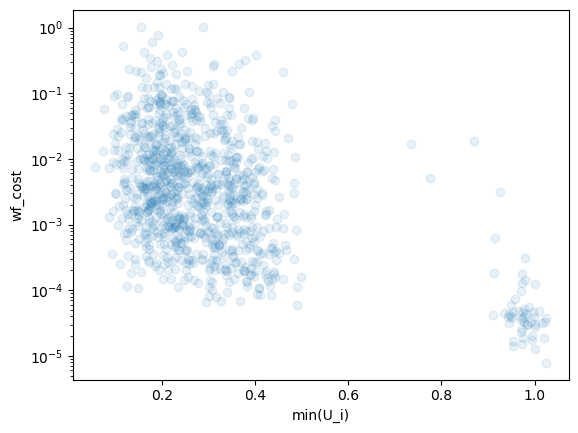

In [67]:
rmin = np.min(dat["U_i"], axis=1)

plt.scatter(rmin, dat["wf_cost"], alpha=0.1)
plt.xlabel("min(U_i)")
plt.ylabel("wf_cost")
plt.yscale("log")

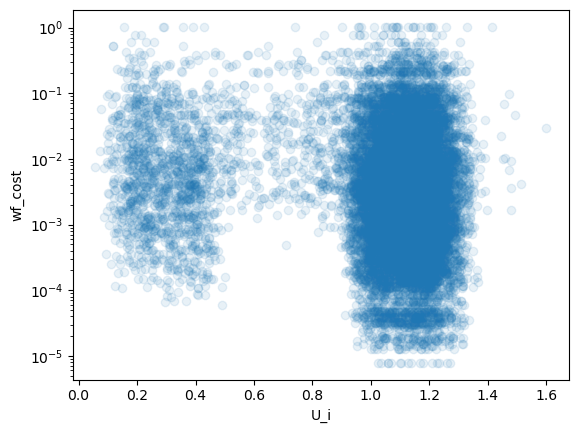

In [72]:
rmin = dat["U_i"]
wfc = np.tile(dat["wf_cost"], (N, 1)).T

plt.scatter(rmin.flatten(), wfc.flatten(), alpha=0.1)
plt.xlabel("U_i")
plt.ylabel("wf_cost")
plt.yscale("log")

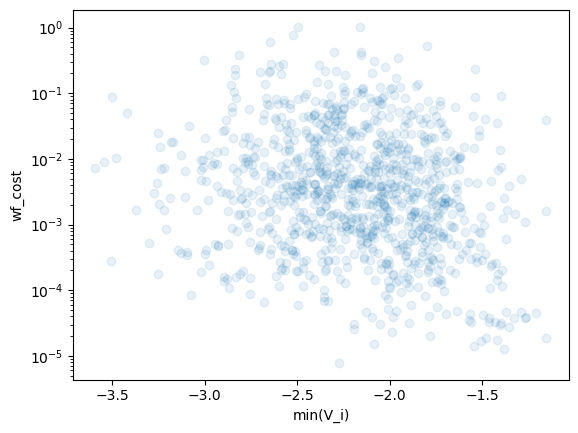

In [73]:
tij = dat["t_ij"]
rmin = np.min(tij, axis=(1, 2))

plt.scatter(rmin, dat["wf_cost"], alpha=0.1)
plt.xlabel("min(V_i)")
plt.ylabel("wf_cost")
plt.yscale("log")

Wannierization failure can be seen much easilier from the Hubbard parameter anomalies.

Success samples are too few that the clusters cannot be well identified.